In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from GalaxyMorphology.DataLoader import GalaxyDataset
# import pandas as pd
import numpy as np

In [8]:
# Load the dataset
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_dataset = GalaxyDataset(
    csv_file='GalaxyMorphology/labels/gz2_train.csv',
    img_dir= 'GalaxyMorphology/images/',
    transform=transform
)

test_dataset = GalaxyDataset(
    csv_file='GalaxyMorphology/labels/gz2_test.csv',
    img_dir= 'GalaxyMorphology/images/',
    transform=transform
)

# Create a DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
test_dataloader = DataLoader(test_dataset, batch_size=1000, shuffle=True, num_workers=4)

# Labels mapping
labels = [
    'Elliptical galxy',
    'Spiral galaxy',
    # 'Barred spiral galxy',
    'Edge-on disk galxy',
    'Star'
]

In [ ]:
# Define neural network
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Sequential(
            nn.Linear(32768, 4096), nn.ReLU(),
            nn.Linear(4096, 1024),  nn.ReLU(),
            nn.Linear(1024, 512),   nn.ReLU(),
            nn.Linear(512, 64),     nn.ReLU(),
            nn.Linear(64, 4)
        )
    
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [10]:
n_Epoch = 10
n_train = len(train_dataloader)

Loss = np.zeros((n_train//100 + 1) * n_Epoch, dtype=np.float16)
Accuracy = np.zeros(n_Epoch+1, dtype=np.float16)

# Train function
def train(model, device, train_dataloader, optimizer, criterion, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_dataloader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx*len(data)}/{len(train_dataloader.dataset)} ({100.*batch_idx / len(train_dataloader):.0f}%)]\tLoss: {loss.item():.6f}')
            # print((epoch-1)*(n_train//100 + 1) + batch_idx//100)
            Loss[(epoch-1)*(n_train//100 + 1) + batch_idx//100] = loss.item()

# Test function
def test(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    
    test_loss /= len(test_loader.dataset)
    accuracy = 100.*correct / len(test_loader.dataset)
    print(f'Test set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.0f}%)')
    return accuracy

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train the model
Accuracy[0] = test(model, device, test_dataloader, criterion)
for epoch in range(1, n_Epoch+1):
    train(model, device, train_dataloader, optimizer, criterion, epoch)
    Accuracy[epoch] = test(model, device, test_dataloader, criterion)

cuda


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1000x32768 and 131072x4096)

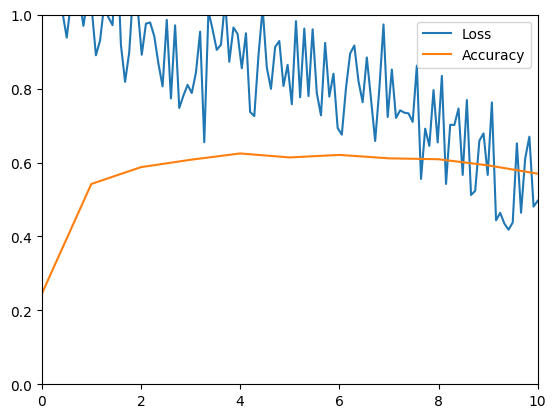

In [ ]:
import matplotlib.pyplot as plt

x_loss = np.linspace(0,n_Epoch,len(Loss))
x_accuracy = np.linspace(0, n_Epoch, n_Epoch+1, dtype=int)

# Layout
fig = plt.figure()
ax = fig.add_subplot(111)

# Plot
ax.plot(x_loss, Loss, label='Loss')
ax.plot(x_accuracy, Accuracy/100, label='Accuracy')

# Details
ax.set_xlim(0, n_Epoch)
ax.set_ylim(0, 1)
ax.legend()

# Output
fig.savefig('LossPlot.png')

In [ ]:
def plot_image(predictions_array, true_label, img):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img.permute(1,2,0))

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% \n({})".format(
            labels[predicted_label],
            100*np.max(predictions_array),
            labels[true_label]
        ),
        color=color
    )

def plot_value_array(predictions_array, true_label):
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(5), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

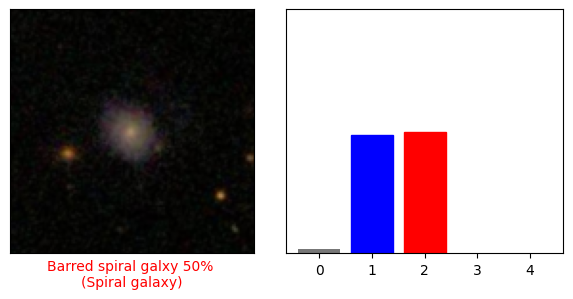

In [ ]:
sample_idx = torch.randint(len(test_dataset), size=(1,)).item()
output = model(test_dataset[sample_idx][0].unsqueeze(0).to(device))
probability = nn.functional.softmax(output, dim=1).cpu().detach().numpy()[0]

# Plot
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plot_image(
    predictions_array=probability,
    true_label=test_dataset[sample_idx][1],
    img=test_dataset[sample_idx][0]
)
plt.subplot(1, 2, 2)
plot_value_array(
    predictions_array=probability,
    true_label=test_dataset[sample_idx][1],
)
plt.tight_layout()
plt.savefig(f'prediction{sample_idx}.png')
plt.show()